# Customer Churn Prediction and RFM Analysis



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load and Explore Customer Data

**Objective**: Load the customer dataset and perform initial exploration to understand data structure and content.

**Operations**:
- Load CSV file containing customer information
- Display first few rows to inspect data types and values
- Remove unnecessary columns (customer_id) to focus on features relevant to analysis
- Check data dimensions and missing values

In [2]:
# Load customer dataset
df = pd.read_csv(r"C:\\Users\\navee\\Downloads\\Customers.csv")
df.head()

,customer_id,age,gender,state,city,income_level,top_category,device_type,acquisition_channel,loyalty_tier,...,returns_ratio,discount_dependency,avg_order_value,frequency,seasonal_spike_factor,monetary_value,time_between_purchases,recency,net_promoter_score,churn
0,C00001,57,Female,Telangana,Hyderabad,High,Fashion,Mobile,Organic Search,Prime,...,0.34,Medium,4268,8,1.13,38583,46,73,41,0
1,C00002,57,Female,Maharashtra,Mumbai,Medium,Beauty,Desktop,Organic Search,Non-Prime,...,0.08,High,1415,2,1.11,3141,182,280,32,0
2,C00003,34,Male,Telangana,Hyderabad,Medium,Electronics,Mobile,Influencer,Prime,...,0.06,Medium,16803,8,1.21,162653,46,24,81,0
3,C00004,34,Male,Karnataka,Mysuru,Medium,Books,Mobile,Organic Search,Non-Prime,...,0.04,Medium,908,1,1.11,1008,365,529,25,1
4,C00005,35,Female,Kerala,Kochi,Low,Home & Kitchen,Mobile,Influencer,Prime,...,0.09,Medium,2899,9,1.06,27656,41,49,77,0


In [3]:
# Drop irrelevant identifier column
df.drop("customer_id", axis=1, inplace=True)

## Exploratory Data Analysis with Visualizations

**Objective**: Understand data distributions and relationships between features and churn status.

**Key Analyses**:
- **Churn Distribution**: Count plot showing overall churn rate
- **Recency Analysis**: Box plot of customer recency by churn status
- **Frequency Analysis**: Box plot of session frequency by churn status
- **NPS Analysis**: Box plot of Net Promoter Score by churn status
- **Cart Abandonment**: Box plot of cart abandonment rate by churn status
- **Order Value**: Box plot of average order value by churn status
- **Device Type**: Count plot showing device distribution across churn groups
- **Loyalty Tier**: Count plot showing loyalty tier distribution across churn groups
- **Correlation Matrix**: Heatmap showing feature relationships

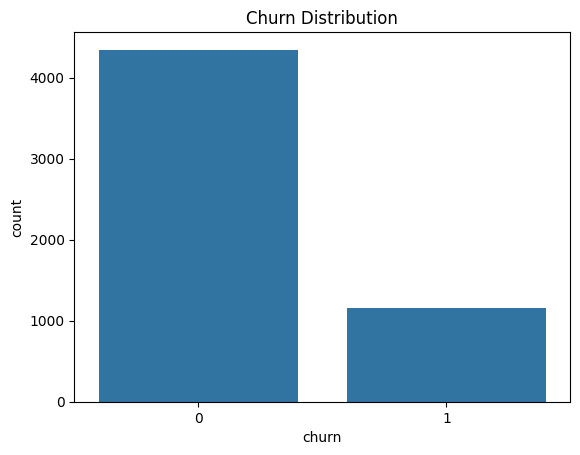

In [4]:
# Visualize overall churn distribution
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

**Insight**: This plot shows the proportion of churned vs retained customers in the dataset.

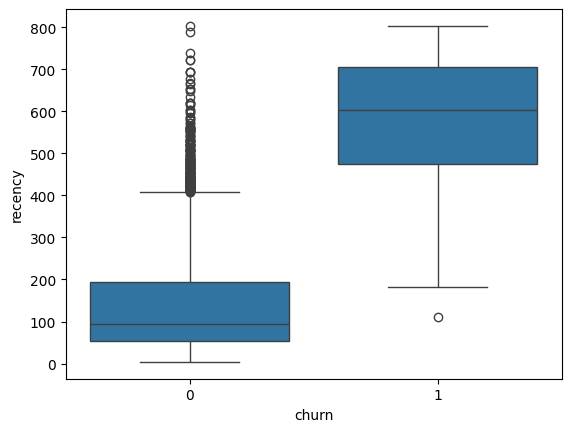

In [5]:
# Analyze recency by churn status
sns.boxplot(x="churn", y="recency", data=df)
plt.show()

**Insight**: Box plot reveals if customers who churned had different recency patterns (e.g., last purchase timing).

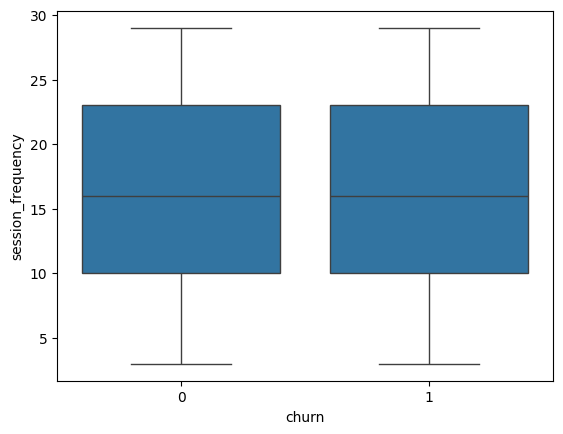

In [6]:
# Analyze session frequency by churn status
sns.boxplot(x="churn", y="session_frequency", data=df)
plt.show()

**Insight**: Customers who churn typically show lower session frequency, indicating reduced engagement.

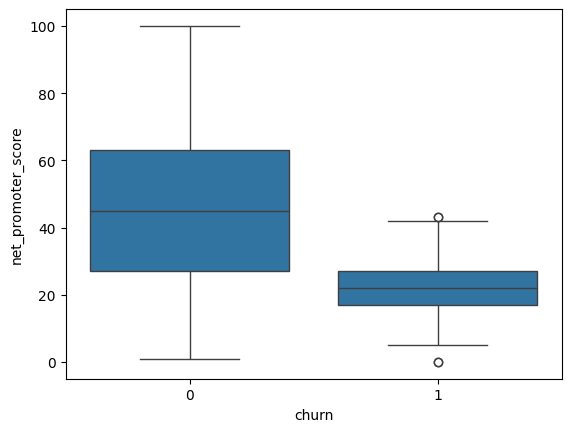

In [7]:
# Analyze NPS (Net Promoter Score) by churn status
sns.boxplot(x="churn", y="net_promoter_score", data=df)
plt.show()

**Insight**: Lower NPS scores often correlate with higher churn likelihood, showing customer satisfaction's importance.

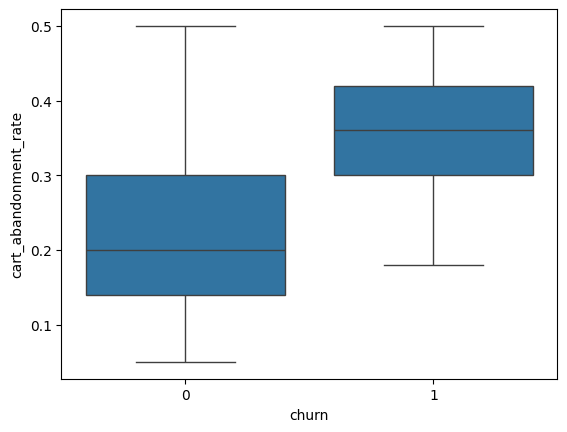

In [8]:
# Analyze cart abandonment rate by churn status
sns.boxplot(x="churn", y="cart_abandonment_rate", data=df)
plt.show()

**Insight**: Higher cart abandonment rates may indicate customers are losing interest or facing friction in the purchase process.

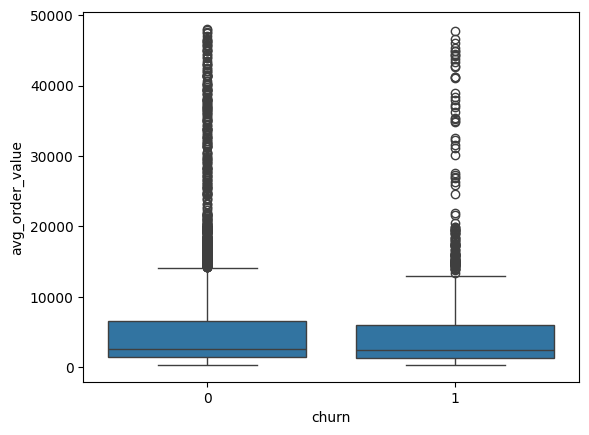

In [9]:
# Analyze average order value by churn status
sns.boxplot(x="churn", y="avg_order_value", data=df)
plt.show()

**Insight**: Churned customers may have lower average order values, suggesting lower customer lifetime value.

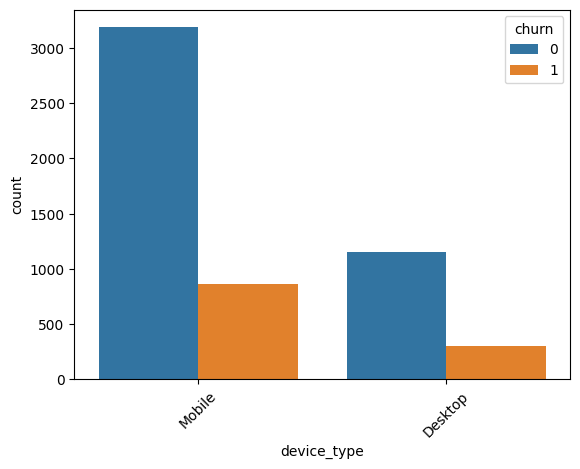

In [10]:
# Analyze device type distribution across churn groups
sns.countplot(x="device_type", hue="churn", data=df)
plt.xticks(rotation=45)
plt.show()

**Insight**: Different device types (mobile, desktop, tablet) may have varying churn rates, revealing user experience issues.

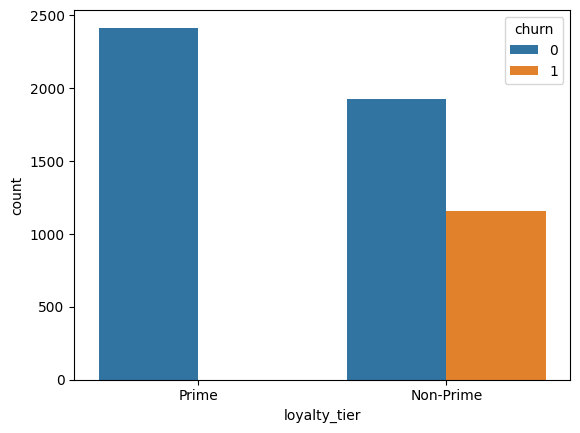

In [11]:
# Analyze loyalty tier distribution across churn groups
sns.countplot(x="loyalty_tier", hue="churn", data=df)
plt.show()

**Insight**: Higher loyalty tiers typically show lower churn rates, validating the loyalty program's effectiveness.

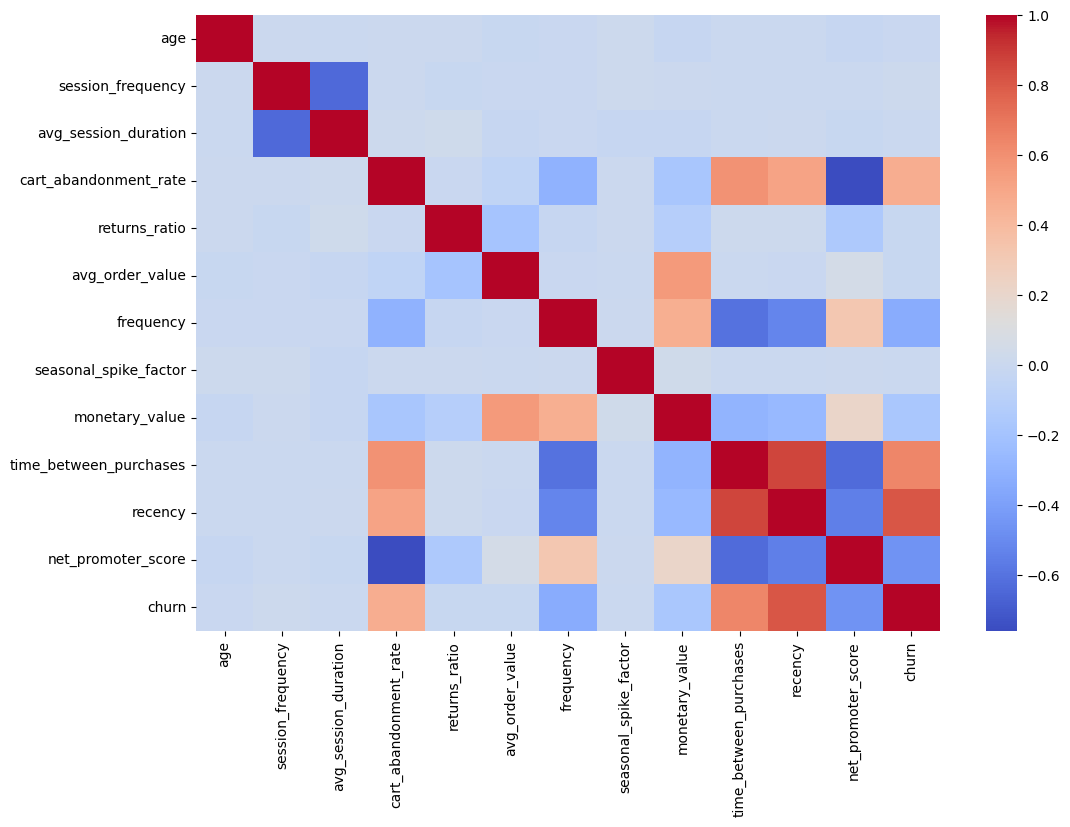

In [12]:
# Create correlation heatmap for all numeric features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

**Insight**: Heat map identifies which features are strongly correlated. Strong correlations can inform feature selection and model improvement strategies.

## Feature Engineering

**Objective**: Create new features that better capture customer behavior and improve model predictive power.

**New Feature**:
- **Engagement Score**: Product of session frequency and average session duration, creating a composite metric of customer engagement
  - Formula: `engagement_score = session_frequency × avg_session_duration`
  - Rationale: Captures both frequency and depth of customer interactions

In [13]:
# Create engagement score feature
df["engagement_score"] = df["session_frequency"] * df["avg_session_duration"]

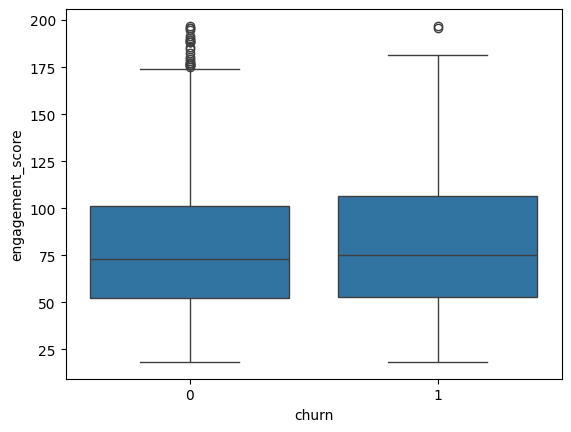

In [14]:
# Visualize engagement score relationship with churn
sns.boxplot(x="churn", y="engagement_score", data=df)
plt.show()

**Insight**: Engagement score shows a clear differentiation between churned and retained customers, making it a valuable predictive feature.

## Data Preprocessing for Modeling

**Objective**: Prepare data for machine learning model training.

**Steps**:
1. **Check Class Balance**: Examine churn distribution to understand if data is imbalanced
2. **Encode Categorical Variables**: Convert categorical features to numeric using one-hot encoding (drop_first=True to avoid multicollinearity)
3. **Train-Test Split**: Divide data into 80% training and 20% testing sets with random_state=42 for reproducibility
4. **Prepare Features and Target**: Separate independent variables (X) and dependent variable (y)

In [15]:
# Check churn class distribution
print("Churn distribution:")
print(df["churn"].value_counts())

Churn distribution:
churn
0    4345
1    1155
Name: count, dtype: int64


**Observation**: This shows if the dataset is balanced or imbalanced, which affects model selection and evaluation metrics.

In [16]:
# One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)

**Explanation**: Converts categorical columns to binary numeric format. `drop_first=True` prevents the dummy variable trap (multicollinearity).

In [17]:
# Split data into training and testing sets
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 4400
Testing set size: 1100


**Explanation**: 
- **X**: All features except the target variable
- **y**: Target variable (churn)
- **train_test_split**: Randomly divides data with 80% for training and 20% for testing
- **random_state=42**: Ensures reproducible results across runs

## Random Forest Classification Model

**Objective**: Train a Random Forest classifier to predict customer churn.

**Model Configuration**:
- **Algorithm**: Random Forest (ensemble of decision trees)
- **n_estimators**: 100 decision trees
- **random_state**: 42 (for reproducibility)

**Advantages of Random Forest**:
- Handles non-linear relationships
- Provides feature importance rankings
- Robust to outliers and missing values
- Naturally handles multi-class problems

In [18]:
# Initialize and train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


**Model Training**: The fit() method trains the model on X_train and y_train, learning patterns in the training data.

##  Model Evaluation Metrics

**Objective**: Evaluate model performance using comprehensive metrics.

**Evaluation Metrics Explained**:
1. **Accuracy**: Overall correctness of predictions
2. **Precision**: Of predicted churns, how many actually churned (True Positives / (True Positives + False Positives))
3. **Recall**: Of actual churns, how many were correctly identified (True Positives / (True Positives + False Negatives))
4. **F1-Score**: Harmonic mean of precision and recall
5. **Confusion Matrix**: True/False Positives and Negatives breakdown
6. **ROC-AUC Score**: Area Under the Receiver Operating Characteristic Curve (probability ranking quality)

**Important Note**: For churn prediction, **Recall (especially for churn class)** is MOST IMPORTANT because:
- False Negatives (missing churning customers) are costlier than False Positives
- We want to catch potential churners to intervene and prevent churn

In [19]:
# Generate predictions
y_pred = rf.predict(X_test)

# Print comprehensive classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       860
           1       0.95      0.88      0.91       240

    accuracy                           0.96      1100
   macro avg       0.96      0.93      0.95      1100
weighted avg       0.96      0.96      0.96      1100


Confusion Matrix:
[[850  10]
 [ 30 210]]


**Interpretation Guide**:
- **Confusion Matrix**: 
  - Top-left: True Negatives (correctly identified retained customers)
  - Top-right: False Positives (incorrectly classified as churn)
  - Bottom-left: False Negatives (missed churners - COSTLY!)
  - Bottom-right: True Positives (correctly identified churners)

**Key Metrics for Churn**:
- **Recall for Churn Class** = TP / (TP + FN) - Most important!
- Higher recall means we catch more potential churners

In [20]:
# Calculate ROC-AUC Score
y_prob = rf.predict_proba(X_test)[:, 1]  # Probability of churn
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9913


**ROC-AUC Explanation**:
- Measures the model's ability to distinguish between churn and non-churn classes across all probability thresholds
- Range: 0 to 1
  - 0.5 = Random guessing
  - 1.0 = Perfect classification
- **predict_proba()** returns probabilities instead of binary predictions, better for evaluating ranking quality

##  RFM Analysis Fundamentals

**Objective**: Understand and implement RFM segmentation for customer analysis.

**RFM Components**:

| Component | Definition | Interpretation |
|-----------|-----------|-----------------|
| **R (Recency)** | Days since last customer purchase | Lower = More recent = Better |
| **F (Frequency)** | Number of times customer made purchases/interactions | Higher = More frequent = Better |
| **M (Monetary)** | Total amount spent by customer | Higher = More spending = Better |

**Why RFM Matters**:
- Identifies high-value customers for retention
- Segments customers for targeted marketing campaigns
- Predicts future purchasing behavior
- Guides resource allocation for customer success initiatives

In [21]:
# Extract RFM features from the dataset
rfm = df[['recency', 'session_frequency', 'avg_order_value']].copy()

# Rename columns for clarity
rfm.columns = ['R', 'F', 'M']

print("RFM Dataset:")
print(rfm.head())
print(f"\nDataset shape: {rfm.shape}")

RFM Dataset:
     R   F      M
0   73  25   4268
1  280   5   1415
2   24  13  16803
3  529  19    908
4   49  18   2899

Dataset shape: (5500, 3)


**Features Mapping**:
- **R (Recency)**: recency - Days since last purchase
- **F (Frequency)**: session_frequency - Interaction frequency
- **M (Monetary)**: avg_order_value - Average spending per order

## RFM Scoring and Segmentation

**Objective**: Convert RFM metrics into scores and segment customers into meaningful groups.

**Scoring Logic Using Quartiles (pd.qcut)**:

1. **R_Score (Recency Score)**:
   - Lower recency (more recent) = Higher score
   - Quartiles: Newest customers get score 4, oldest get score 1

2. **F_Score (Frequency Score)**:
   - Higher frequency = Higher score
   - Quartiles: Most frequent customers get score 4, least frequent get score 1

3. **M_Score (Monetary Score)**:
   - Higher spending = Higher score
   - Quartiles: Biggest spenders get score 4, smallest get score 1

**RFM Composite Score**:
- Sum of three individual scores (range: 3-12)
- Higher total = Higher customer value

**Customer Segments**:
- **Champions** (10-12): Best customers, highest value and engagement
- **Loyal Customers** (7-9): Good customers, consistent engagement and spending
- **Potential** (5-6): Mid-tier customers, need nurturing and engagement
- **At Risk** (3-4): Lowest value, high churn risk, need retention strategies

In [22]:
# Create RFM scores using quartile binning
rfm['R_Score'] = pd.qcut(rfm['R'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['F'], 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['M'], 4, labels=[1, 2, 3, 4])

print("Score Distribution:")
print(rfm[['R', 'R_Score', 'F', 'F_Score', 'M', 'M_Score']].head(10))

Score Distribution:
     R R_Score   F F_Score      M M_Score
0   73       3  25       4   4268       3
1  280       2   5       1   1415       1
2   24       4  13       2  16803       4
3  529       1  19       3    908       1
4   49       4  18       3   2899       3
5  402       1  10       1    858       1
6   47       4  25       4  43846       4
7   30       4  20       3   3720       3
8   78       3  10       1   1944       2
9  652       1  28       4   1962       2


**pd.qcut() Explanation**:
- Divides data into quartiles (4 equal-sized groups)
- `R_Score`: [4, 3, 2, 1] - Reverse order because lower recency is better
- `F_Score` & `M_Score`: [1, 2, 3, 4] - Natural order because higher values are better

In [23]:
# Calculate composite RFM score
rfm['RFM_score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

print("\nRFM Score Distribution:")
print(rfm['RFM_score'].describe())
print(rfm['RFM_score'].value_counts().sort_index())


RFM Score Distribution:
count    5500.000000
mean        7.425091
std         1.924665
min         3.000000
25%         6.000000
50%         7.000000
75%         9.000000
max        12.000000
Name: RFM_score, dtype: float64
RFM_score
3       94
4      264
5      553
6      879
7     1026
8     1068
9      806
10     501
11     237
12      72
Name: count, dtype: int64


**Score Range Interpretation**:
- Minimum: 3 (all scores = 1)
- Maximum: 12 (all scores = 4)
- Average: Around 6-7

In [24]:
# Define segmentation function based on RFM score
def segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 7:
        return "Loyal Customers"
    elif score >= 5:
        return "Potential"
    else:
        return "At Risk"

# Apply segmentation
rfm['Segment'] = rfm['RFM_score'].apply(segment)

print("\nSegment Distribution:")
print(rfm['Segment'].value_counts())


Segment Distribution:
Segment
Loyal Customers    2900
Potential          1432
Champions           810
At Risk             358
Name: count, dtype: int64


**Segmentation Thresholds**:
- Champions: ≥10 points (most valuable)
- Loyal: 7-9 points
- Potential: 5-6 points
- At Risk: ≤4 points (highest churn risk)

## RFM Business Insights

**Objective**: Analyze customer segments and their relationship to churn behavior.

**Analysis Goals**:
- Identify which segments have highest/lowest churn rates
- Understand segment sizes
- Develop targeted retention strategies
- Validate business intuition about customer value vs. churn

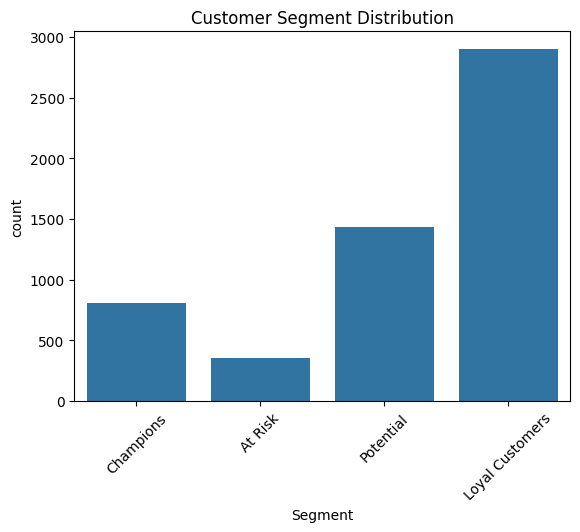

In [25]:
# Visualize segment distribution
sns.countplot(x="Segment", data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segment Distribution")
plt.show()

**Insight**: Shows the proportion of customers in each segment. Typically, most customers are in mid-tiers.

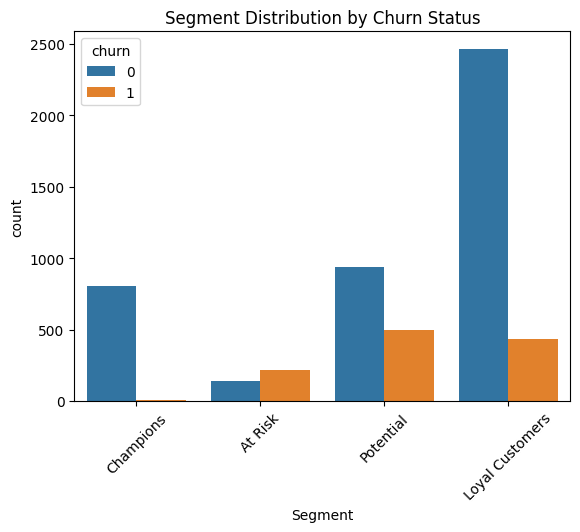

In [26]:
# Add churn data to RFM segments
rfm['churn'] = df['churn']

# Visualize segment distribution by churn status
sns.countplot(x="Segment", hue="churn", data=rfm)
plt.xticks(rotation=45)
plt.title("Segment Distribution by Churn Status")
plt.show()

**Key Business Insights**:
- **Champions**: Show LOW churn rates (golden customers, focus on retention and upselling)
- **Loyal Customers**: Show MODERATE churn rates (stable base, maintain engagement)
- **Potential**: Show HIGHER churn rates (nurture these customers to prevent defection)
- **At Risk**: Show HIGHEST churn rates (aggressive retention campaigns recommended)

**Strategic Recommendations**:
1. **Champions**: VIP treatment, exclusive perks, early access to new products
2. **Loyal**: Regular engagement, loyalty rewards, personalized recommendations
3. **Potential**: Re-engagement campaigns, special offers, improved communication
4. **At Risk**: Win-back offers, personalized outreach, feedback collection

In [27]:
# Calculate churn rate by segment
churn_by_segment = rfm.groupby('Segment')['churn'].agg(['sum', 'count', 'mean'])
churn_by_segment.columns = ['Churned_Count', 'Total_Customers', 'Churn_Rate']
print("\nChurn Rate by Segment:")
print(churn_by_segment)


Churn Rate by Segment:
                 Churned_Count  Total_Customers  Churn_Rate
Segment                                                    
At Risk                    217              358    0.606145
Champions                    7              810    0.008642
Loyal Customers            437             2900    0.150690
Potential                  494             1432    0.344972


**Analysis Output**:
- **Churned_Count**: Number of customers who churned in each segment
- **Total_Customers**: Total customers in each segment
- **Churn_Rate**: Percentage of customers who churned (ranges 0-1)

This validates the expected pattern: higher-value segments have lower churn rates.

## K-Means Clustering on RFM Features

**Objective**: Apply unsupervised machine learning to discover natural customer groupings.

**Approach**:
1. **Standardization**: Scale RFM features to have mean=0 and std=1 (StandardScaler)
   - Reason: K-Means uses distance calculations; unscaled features with different ranges bias the algorithm
2. **K-Means Algorithm**: Find k=4 clusters that minimize within-cluster distances
3. **Visualization**: 2D plot of Frequency vs Monetary colored by cluster

**Why K-Means?**:
- Unsupervised learning (no target variable needed)
- Discovers hidden patterns in data
- Complements RFM segmentation with data-driven approach
- Results can differ from RFM (RFM is business-rule driven, K-Means is data-driven)

In [28]:
# Prepare features for clustering
rfm_features = rfm[['R', 'F', 'M']].copy()

# Standardize features to have mean=0 and std=1
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['KMeans_Segment'] = kmeans.fit_predict(rfm_scaled)

print("K-Means Cluster Centers (Scaled):")
print(kmeans.cluster_centers_)
print(f"\nCluster Distribution:")
print(rfm['KMeans_Segment'].value_counts().sort_index())

K-Means Cluster Centers (Scaled):
[[-0.46558254  0.92575335 -0.21394185]
 [-0.11366944 -0.01109041  3.26648424]
 [-0.45187719 -0.85294004 -0.1936678 ]
 [ 1.65967879  0.03927449 -0.18129698]]

Cluster Distribution:
KMeans_Segment
0    1918
1     314
2    2129
3    1139
Name: count, dtype: int64


**Standardization Benefits**:
- Ensures each feature contributes equally to distance calculations
- Without scaling, Monetary (larger values) would dominate the clustering
- StandardScaler formula: (X - mean) / std

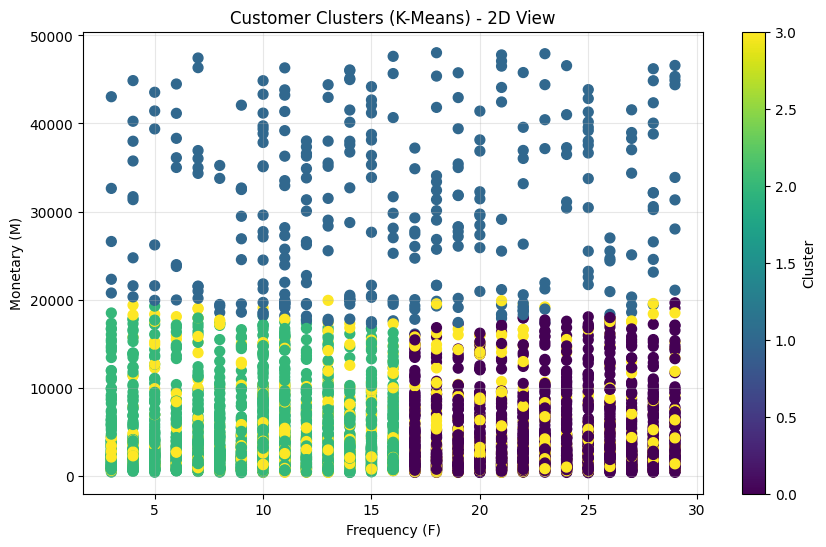

In [29]:
# Visualize clusters in 2D (Frequency vs Monetary)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rfm['F'], rfm['M'], c=rfm['KMeans_Segment'], cmap='viridis', s=50)
plt.xlabel('Frequency (F)')
plt.ylabel('Monetary (M)')
plt.title('Customer Clusters (K-Means) - 2D View')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

**Cluster Interpretation**:
- Each color represents a distinct cluster
- Cluster 0, 1, 2, 3 differ in their Frequency-Monetary characteristics
- Some clusters may overlap when visualizing in 2D (3D data projected to 2D)

##  3D Interactive Visualization with Plotly

**Objective**: Create interactive 3D visualizations of RFM clusters for deeper exploration.

**Visualization Methods**:
1. **Method 1**: Using `plotly.express.scatter_3d()` - High-level interface with automatic color mapping
2. **Method 2**: Using `plotly.graph_objects.Scatter3d()` - Low-level interface with fine-grained control

**Interactive Features**:
- Rotate the plot by dragging
- Zoom with scroll wheel
- Hover to see data point information
- Click legend items to toggle clusters
- Pan by right-clicking and dragging

**Advantages over 2D Plots**:
- Visualizes all three dimensions simultaneously
- Better representation of cluster separation
- Interactive exploration reveals patterns in 3D space

In [30]:
import plotly.express as px
import plotly.graph_objects as go

# Ensure cluster labels are strings for better color mapping
rfm['Cluster'] = rfm['KMeans_Segment'].astype(str)

# Method 1: High-level Plotly Express - Clean and simple
fig = px.scatter_3d(rfm, 
                    x='R', y='F', z='M',
                    color='Cluster',
                    title='Interactive 3D RFM Customer Segments (Method 1)',
                    labels={'R': 'Recency (days)', 
                            'F': 'Frequency (times)', 
                            'M': 'Monetary (value)', 
                            'Cluster': 'Segment'},
                    color_discrete_sequence=["#C62E2E", '#4ECDC4', "#3E56F4", '#FFA07A'])

# Customize markers for better visibility
fig.update_traces(marker=dict(size=5, 
                              opacity=0.8, 
                              line=dict(width=0.5, color='DarkSlateGrey')))

fig.show()

**Method 1 Customization**:
- **color_discrete_sequence**: Custom colors for each cluster
- **marker size=5**: Point size in 3D space
- **opacity=0.8**: Transparency (0=invisible, 1=opaque)
- **line.width**: Border thickness for each point
- **line.color**: Border color for each point

In [31]:
# Method 2: Low-level Plotly Graph Objects - Full control
fig = go.Figure(data=[go.Scatter3d(
    x=rfm['R'],
    y=rfm['F'],
    z=rfm['M'],
    mode='markers',
    marker=dict(
        size=6,
        color=rfm['KMeans_Segment'],  # Numeric color mapping
        colorscale='Viridis',         # Color gradient scheme
        showscale=True,               # Display color bar
        colorbar=dict(
            title="Cluster ID",
            thickness=15,
            len=0.7
        ),
        opacity=0.8
    ),
    text=rfm['KMeans_Segment'],       # Hover text
    hoverinfo='text'
)])

# Customize layout
fig.update_layout(
    title='Interactive 3D RFM Cluster Analysis (Method 2)',
    scene=dict(
        xaxis_title='Recency (days)',
        yaxis_title='Frequency (times)',
        zaxis_title='Monetary (value)',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    width=900,
    height=700,
    font=dict(size=12)
)

fig.show()

**Method 2 Customization**:
- **colorscale='Viridis'**: Color gradient from purple to yellow
- **showscale=True**: Displays color bar on the right
- **camera**: Controls initial viewing angle (eye position in 3D)
- **width/height**: Canvas dimensions in pixels

**Comparison**:
- Method 1: Faster to implement, good for quick exploration
- Method 2: More control, better for presentations and specific styling needs

In [33]:
# Print cluster distribution and statistics
print("\n" + "="*60)
print("CLUSTER DISTRIBUTION AND CHARACTERISTICS")
print("="*60)

print("\nCluster Distribution (Count):")
print(rfm['Cluster'].value_counts().sort_index())

print("\n\nCluster Characteristics (Mean Values):")
cluster_stats = rfm.groupby('Cluster')[['R', 'F', 'M']].mean().round(2)
cluster_stats.columns = ['Avg Recency', 'Avg Frequency', 'Avg Monetary']
print(cluster_stats)

print("\n\nCluster Characteristics (Standard Deviation):")
cluster_std = rfm.groupby('Cluster')[['R', 'F', 'M']].std().round(2)
cluster_std.columns = ['Std Recency', 'Std Frequency', 'Std Monetary']
print(cluster_std)


CLUSTER DISTRIBUTION AND CHARACTERISTICS

Cluster Distribution (Count):
Cluster
0    1918
1     314
2    2129
3    1139
Name: count, dtype: int64


Cluster Characteristics (Mean Values):
         Avg Recency  Avg Frequency  Avg Monetary
Cluster                                          
0             130.29          23.15       3977.54
1             208.51          16.10      30358.05
2             133.34           9.78       4124.09
3             600.21          16.49       4217.73


Cluster Characteristics (Standard Deviation):
         Std Recency  Std Frequency  Std Monetary
Cluster                                          
0             103.90           3.72       3890.92
1             195.99           6.94       9289.30
2             105.73           3.82       3941.07
3             122.98           7.11       4370.55


## Cluster Analysis Summary

**Interpretation Guide**:

| Metric | What It Tells You |
|--------|------------------|
| **Avg Recency** | Average days since last purchase (lower = more recent) |
| **Avg Frequency** | Average purchases per period (higher = more active) |
| **Avg Monetary** | Average spending per order (higher = more valuable) |
| **Std Dev** | Variability within cluster (higher = more diverse customers) |

**Business Actions Based on Clusters**:
- **High F, High M Cluster**: Champions - Maximize retention and upsell
- **Low R, Good F,M Cluster**: Loyal - Maintain engagement
- **High R, Low F,M Cluster**: At Risk - Retention campaigns needed
- **Variable Profile Cluster**: Transitional - Monitor closely for changes

**Next Steps**:
1. Compare K-Means clusters with RFM business segments
2. Correlate clusters with actual churn outcomes
3. Develop targeted marketing strategies for each cluster
4. Monitor cluster drift over time to update segmentation
5. Use cluster insights to improve Random Forest churn prediction model